## Project Title - **CancerGuard – SVM Cancer Detection API**

The 6 phases are:
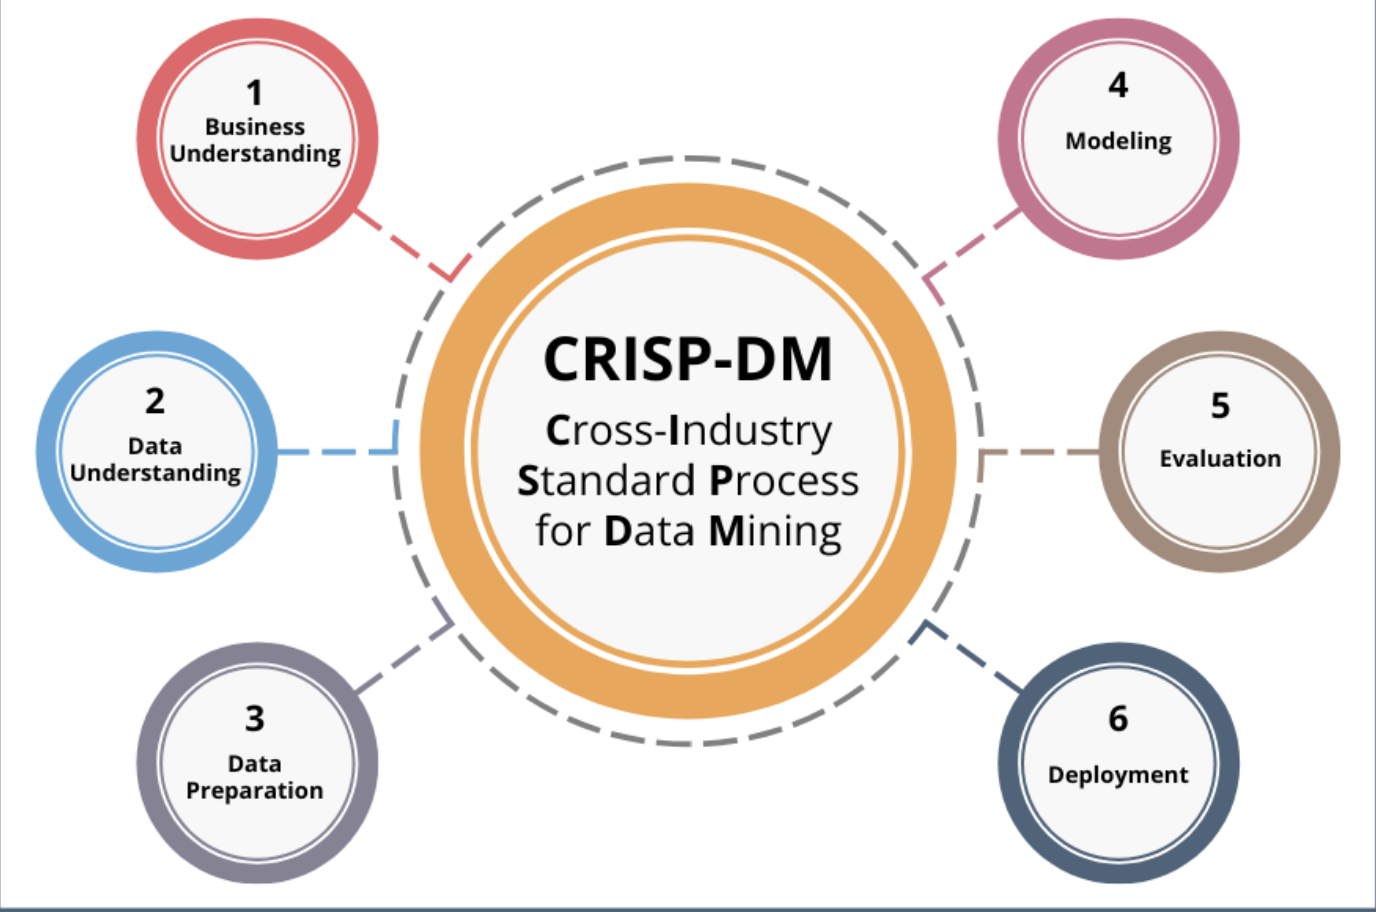

---
# 1️⃣ Business Understanding Phase

# 1.1 Business Problem Statement

Cancer remains one of the leading causes of death worldwide, and early detection plays a critical role in improving survival rates and treatment effectiveness. Traditional diagnostic procedures often require significant medical expertise, laboratory analysis, and time-consuming evaluations.

Healthcare systems increasingly require intelligent, scalable, and automated solutions capable of assisting medical professionals in preliminary cancer risk assessment. Machine learning models can support this process by identifying hidden patterns in clinical data and generating predictive insights with high accuracy.

The CancerGuard project aims to address this challenge by developing a machine learning-powered RESTful API capable of predicting whether cancer is present or absent based on medical input features. The system uses a Support Vector Machine (SVM) classification model integrated into a FastAPI backend service to provide fast, accurate, and scalable predictions.

---

# 1.2 Business Objectives

The primary business objectives of the CancerGuard system are:

## Core Objectives

* Develop an intelligent cancer prediction system using machine learning techniques.
* Provide accurate binary classification of cancer presence.
* Create a scalable REST API service for healthcare integration.
* Enable healthcare developers and researchers to access predictions programmatically.
* Reduce manual effort involved in preliminary diagnostic analysis.
* Provide fast prediction responses suitable for real-time applications.
* Improve accessibility to machine learning-powered healthcare tools.


---

### Step2️⃣ Data Understanding

In [1]:
### Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
warnings.filterwarnings("ignore")

### 2.1 Load the dataset

In [2]:
### Read the dataset
df = pd.read_csv("D:/STUDY/Data_Science_Courses/PROJECTS/2.CancerGuard-SVM/CancerGuard---SVM-Cancer-Detection-API/data/Breast-Cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 2.2 Preview the first  & last rows

In [3]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


### 2.3 Check dataset dimensions

In [4]:
## DATASET DIMENSIONS
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (569, 33)
Number of Rows: 569
Number of Columns: 33


In [5]:
## COLUMN NAMES
print(f"Total Columns: {len(df.columns)}\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Total Columns: 33

01. id
02. diagnosis
03. radius_mean
04. texture_mean
05. perimeter_mean
06. area_mean
07. smoothness_mean
08. compactness_mean
09. concavity_mean
10. concave points_mean
11. symmetry_mean
12. fractal_dimension_mean
13. radius_se
14. texture_se
15. perimeter_se
16. area_se
17. smoothness_se
18. compactness_se
19. concavity_se
20. concave points_se
21. symmetry_se
22. fractal_dimension_se
23. radius_worst
24. texture_worst
25. perimeter_worst
26. area_worst
27. smoothness_worst
28. compactness_worst
29. concavity_worst
30. concave points_worst
31. symmetry_worst
32. fractal_dimension_worst
33. Unnamed: 32


In [6]:
##  DATASET INFORMATION

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Step 3 — Data Quality Assessment

#### Step 3.1 — Missing values

In [7]:
## MISSING VALUE ANALYSIS
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

print("Columns containing missing values:")
display(missing_summary)

Columns containing missing values:


,Missing_Count,Missing_Percentage
Unnamed: 32,569,100.0


#### Step 3.2 — Duplicate rows

In [8]:
## DUPLICATE ROW ANALYSIS

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df)) * 100, 2),
    "%"
)

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


#### Step 3.3 — Unique values per column

In [9]:
#### UNIQUE VALUES PER COLUMN

unique_counts = df.nunique().sort_values()

unique_summary = pd.DataFrame({
    "Unique_Values": unique_counts
})

display(unique_summary)

,Unique_Values
Unnamed: 32,0
diagnosis,2
smoothness_worst,411
symmetry_mean,432
radius_mean,456
radius_worst,457
smoothness_mean,474
texture_mean,479
concave points_worst,492
symmetry_se,498


#### Step 3.4 — Check the target values

In [10]:
## TARGET VARIABLE VALUES

print("Unique diagnosis values:")
print(df["diagnosis"].unique())

print("\nNumber of unique diagnosis values:")
print(df["diagnosis"].nunique())

print("\nDiagnosis value counts:")
print(df["diagnosis"].value_counts())

Unique diagnosis values:
<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Number of unique diagnosis values:
2

Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


- M = Malignant
- B = Benign

#### Step 3.5 — Check for constant columns

In [11]:
## CONSTANT / ZERO-VARIANCE COLUMNS
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant / single-value columns:")
print(constant_columns)

Constant / single-value columns:
['Unnamed: 32']


### Step 4 — Target Variable & Class Balance Analysis

##### 4.1 Calculate class percentages

In [12]:
##  TARGET CLASS DISTRIBUTION

target_counts = df["diagnosis"].value_counts()
target_percentages = df["diagnosis"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(class_distribution)

,Count,Percentage
diagnosis,,
B,357,62.74
M,212,37.26


#### 4.2 Visualize class distribution

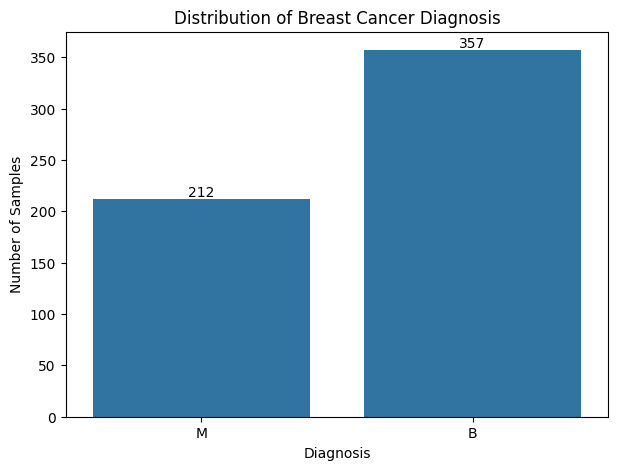

In [13]:
# VISUALIZE TARGET DISTRIBUTION

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### 4.3 Make the labels easier to interpret

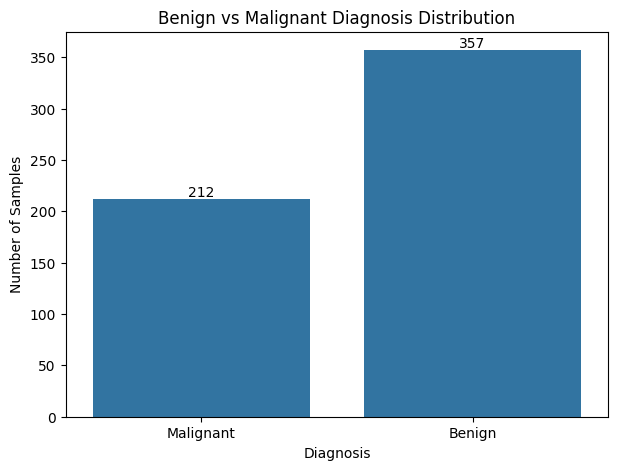

In [14]:
diagnosis_labels = df["diagnosis"].map({
    "B": "Benign",
    "M": "Malignant"
})

plt.figure(figsize=(7, 5))

ax = sns.countplot(x=diagnosis_labels)

plt.title("Benign vs Malignant Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The dataset contains 569 observations, consisting of 357 benign (62.74%) and 212 malignant (37.26%) cases. The target therefore shows a moderate class imbalance, with benign cases occurring approximately 1.68 times as often as malignant cases.

### Step 5 — Descriptive Statistical Analysis

#### Step 5.1 — Select the actual predictive features

In [15]:
## IDENTIFY NUMERICAL PREDICTIVE FEATURES

feature_columns = [
    col for col in df.columns
    if col not in ["id", "diagnosis", "Unnamed: 32"]
]

print("Number of predictive features:", len(feature_columns))
print("\nPredictive features:")
print(feature_columns)

Number of predictive features: 30

Predictive features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


#### Step 5.2 — Descriptive statistics

In [16]:
descriptive_stats = df[feature_columns].describe().T

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


#### Step 5.3 — Check feature scale differences

In [17]:
##  FEATURE RANGE ANALYSIS

feature_ranges = pd.DataFrame({
    "Minimum": df[feature_columns].min(),
    "Maximum": df[feature_columns].max(),
    "Mean": df[feature_columns].mean(),
    "Std_Dev": df[feature_columns].std()
})

feature_ranges["Range"] = (
    feature_ranges["Maximum"] - feature_ranges["Minimum"]
)

feature_ranges = feature_ranges.sort_values(
    "Range",
    ascending=False
)

display(feature_ranges)

,Minimum,Maximum,Mean,Std_Dev,Range
area_worst,185.200000,4254.00000,880.583128,569.356993,4068.800000
area_mean,143.500000,2501.00000,654.889104,351.914129,2357.500000
area_se,6.802000,542.20000,40.337079,45.491006,535.398000
perimeter_worst,50.410000,251.20000,107.261213,33.602542,200.790000
perimeter_mean,43.790000,188.50000,91.969033,24.298981,144.710000
texture_worst,12.020000,49.54000,25.677223,6.146258,37.520000
texture_mean,9.710000,39.28000,19.289649,4.301036,29.570000
radius_worst,7.930000,36.04000,16.269190,4.833242,28.110000
perimeter_se,0.757000,21.98000,2.866059,2.021855,21.223000
radius_mean,6.981000,28.11000,14.127292,3.524049,21.129000


#### Step 5.4 — Compare mean vs median

In [18]:
## MEAN VS MEDIAN ANALYSIS
mean_median = pd.DataFrame({
    "Mean": df[feature_columns].mean(),
    "Median": df[feature_columns].median()
})

mean_median["Difference"] = (
    mean_median["Mean"] - mean_median["Median"]
)

mean_median["Relative_Difference_%"] = (
    abs(mean_median["Difference"]) /
    mean_median["Median"].replace(0, np.nan)
) * 100

mean_median = mean_median.sort_values(
    "Relative_Difference_%",
    ascending=False
)

display(mean_median)

,Mean,Median,Difference,Relative_Difference_%
area_se,40.337079,24.530000,15.807079,64.439784
concave points_mean,0.048919,0.033500,0.015419,46.027301
concavity_mean,0.088799,0.061540,0.027259,44.295281
area_worst,880.583128,686.500000,194.083128,28.271395
perimeter_se,2.866059,2.287000,0.579059,25.319599
radius_se,0.405172,0.324200,0.080972,24.975958
compactness_se,0.025478,0.020450,0.005028,24.587476
concavity_se,0.031894,0.025890,0.006004,23.189325
concavity_worst,0.272188,0.226700,0.045488,20.065498
compactness_worst,0.254265,0.211900,0.042365,19.992942


### Step 6 — Feature Distribution & Skewness Analysis

#### 6.1 Calculate skewness

In [19]:
## FEATURE SKEWNESS

skewness = df[feature_columns].skew()

skewness_summary = pd.DataFrame({
    "Skewness": skewness
})

skewness_summary["Absolute_Skewness"] = (
    skewness_summary["Skewness"].abs()
)

skewness_summary = skewness_summary.sort_values(
    "Absolute_Skewness",
    ascending=False
)

display(skewness_summary)

,Skewness,Absolute_Skewness
area_se,5.447186,5.447186
concavity_se,5.110463,5.110463
fractal_dimension_se,3.923969,3.923969
perimeter_se,3.443615,3.443615
radius_se,3.088612,3.088612
smoothness_se,2.314450,2.314450
symmetry_se,2.195133,2.195133
compactness_se,1.902221,1.902221
area_worst,1.859373,1.859373
fractal_dimension_worst,1.662579,1.662579


#### 6.2 Count features by skewness level

In [20]:
## SKEWNESS CATEGORY SUMMARY
def classify_skewness(value):
    abs_value = abs(value)

    if abs_value < 0.5:
        return "Approximately Symmetric"
    elif abs_value <= 1.0:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"


skewness_summary["Category"] = (
    skewness_summary["Skewness"].apply(classify_skewness)
)

print("Skewness Category Counts:")
print(skewness_summary["Category"].value_counts())

display(skewness_summary)

Skewness Category Counts:
Category
Highly Skewed              22
Moderately Skewed           4
Approximately Symmetric     4
Name: count, dtype: int64


,Skewness,Absolute_Skewness,Category
area_se,5.447186,5.447186,Highly Skewed
concavity_se,5.110463,5.110463,Highly Skewed
fractal_dimension_se,3.923969,3.923969,Highly Skewed
perimeter_se,3.443615,3.443615,Highly Skewed
radius_se,3.088612,3.088612,Highly Skewed
smoothness_se,2.314450,2.314450,Highly Skewed
symmetry_se,2.195133,2.195133,Highly Skewed
compactness_se,1.902221,1.902221,Highly Skewed
area_worst,1.859373,1.859373,Highly Skewed
fractal_dimension_worst,1.662579,1.662579,Highly Skewed


#### 6.3 Distribution plots for selected features

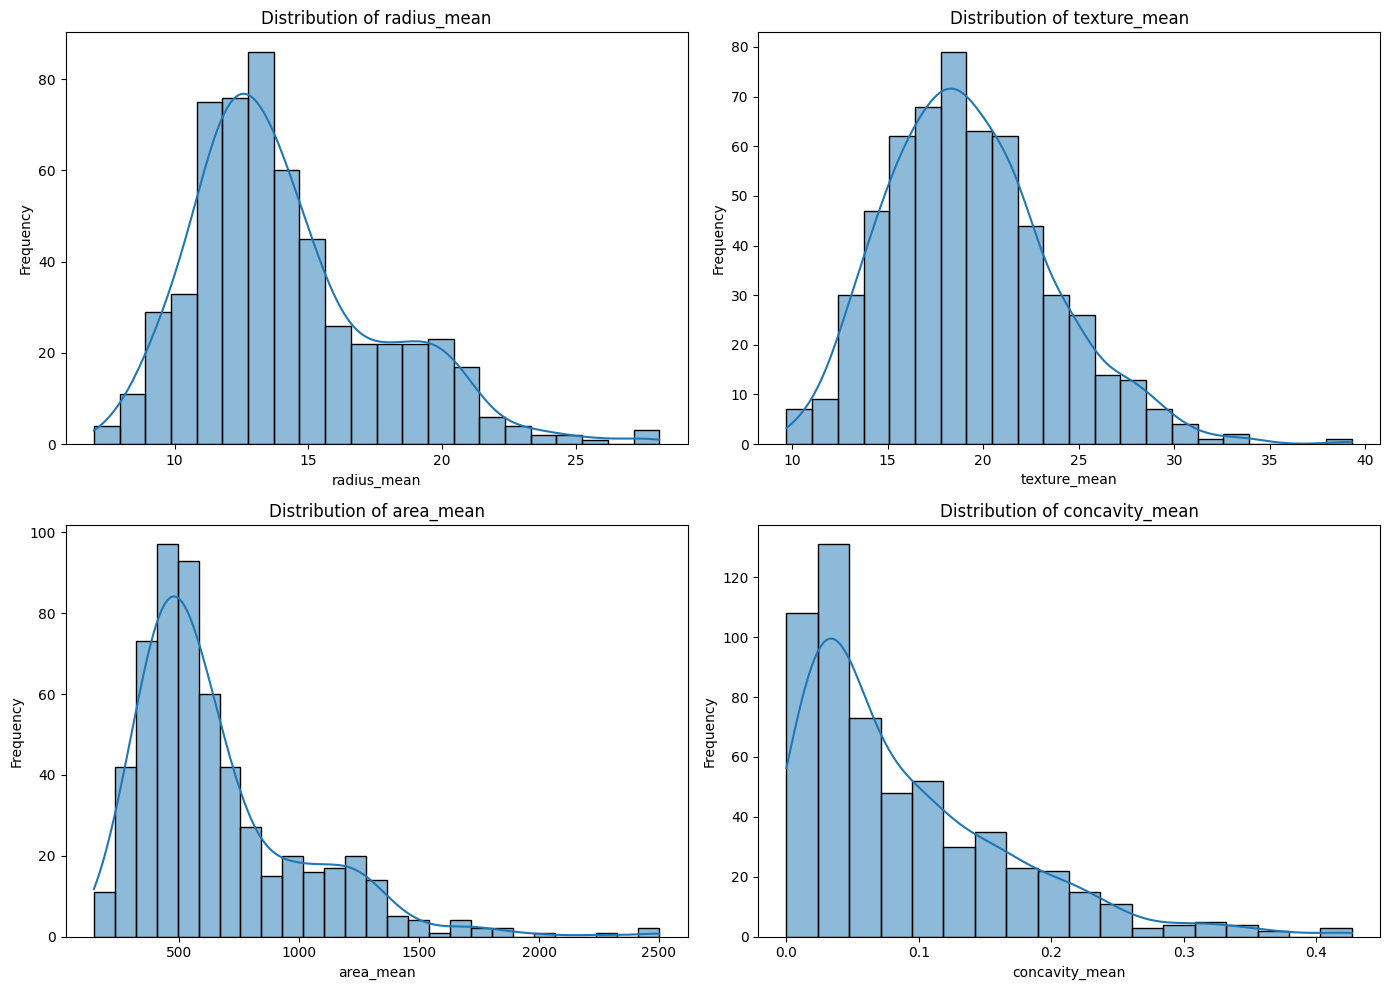

In [21]:
## DISTRIBUTIONS OF SELECTED FEATURES
selected_features = [
    "radius_mean",
    "texture_mean",
    "area_mean",
    "concavity_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, feature in enumerate(selected_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {feature}"
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### 6.4 Compare distributions by diagnosis

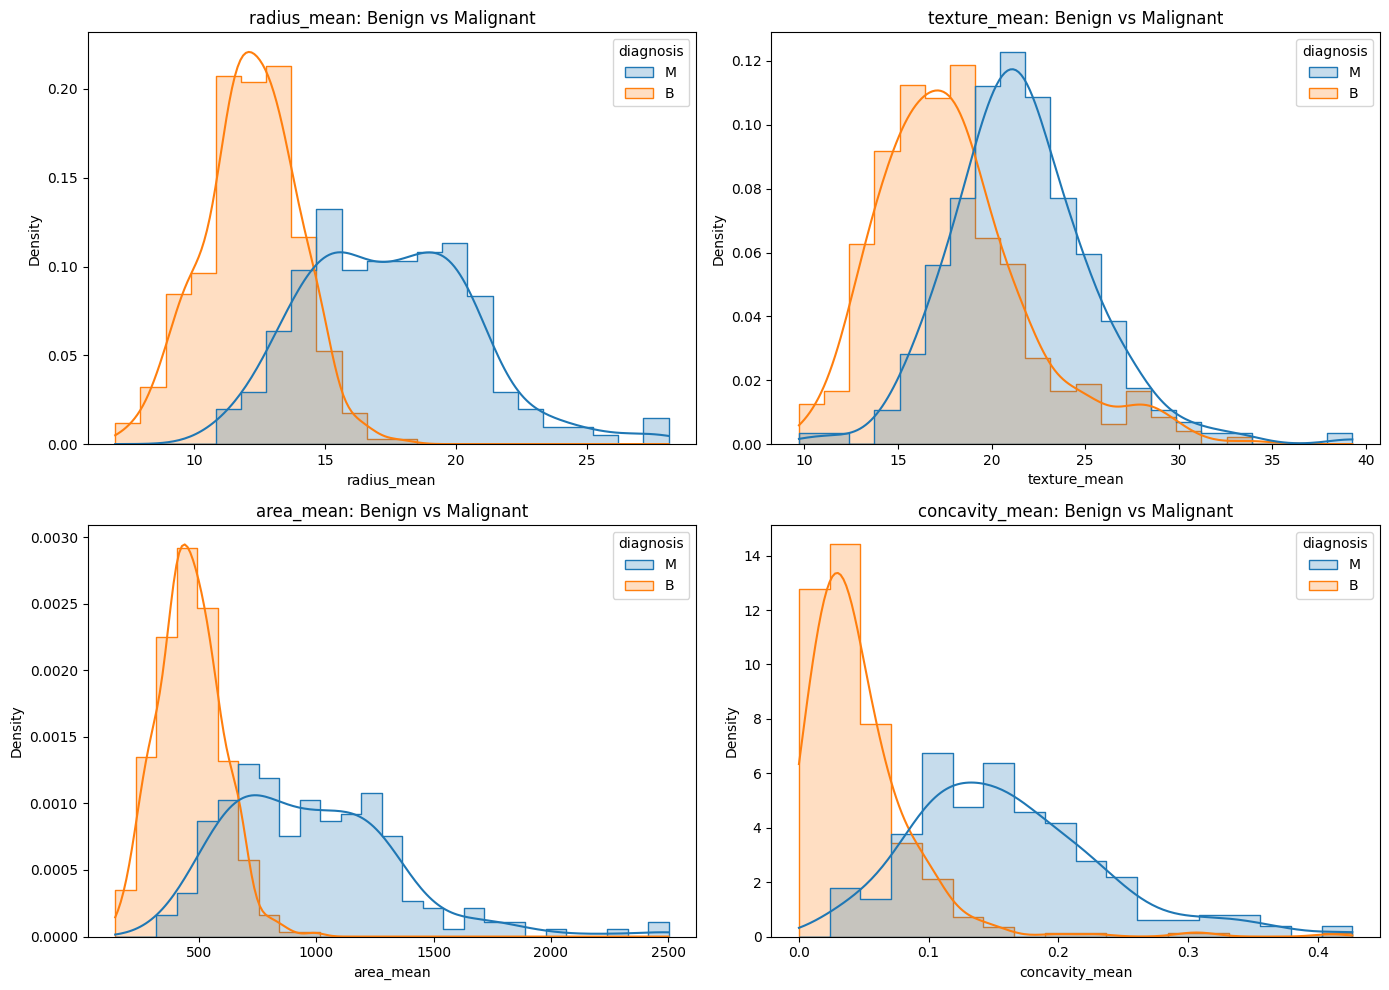

In [22]:
##  FEATURE DISTRIBUTIONS BY DIAGNOSIS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, feature in enumerate(selected_features):

    sns.histplot(
        data=df,
        x=feature,
        hue="diagnosis",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature}: Benign vs Malignant"
    )

    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

#### 6.5 Boxplots for potential outliers

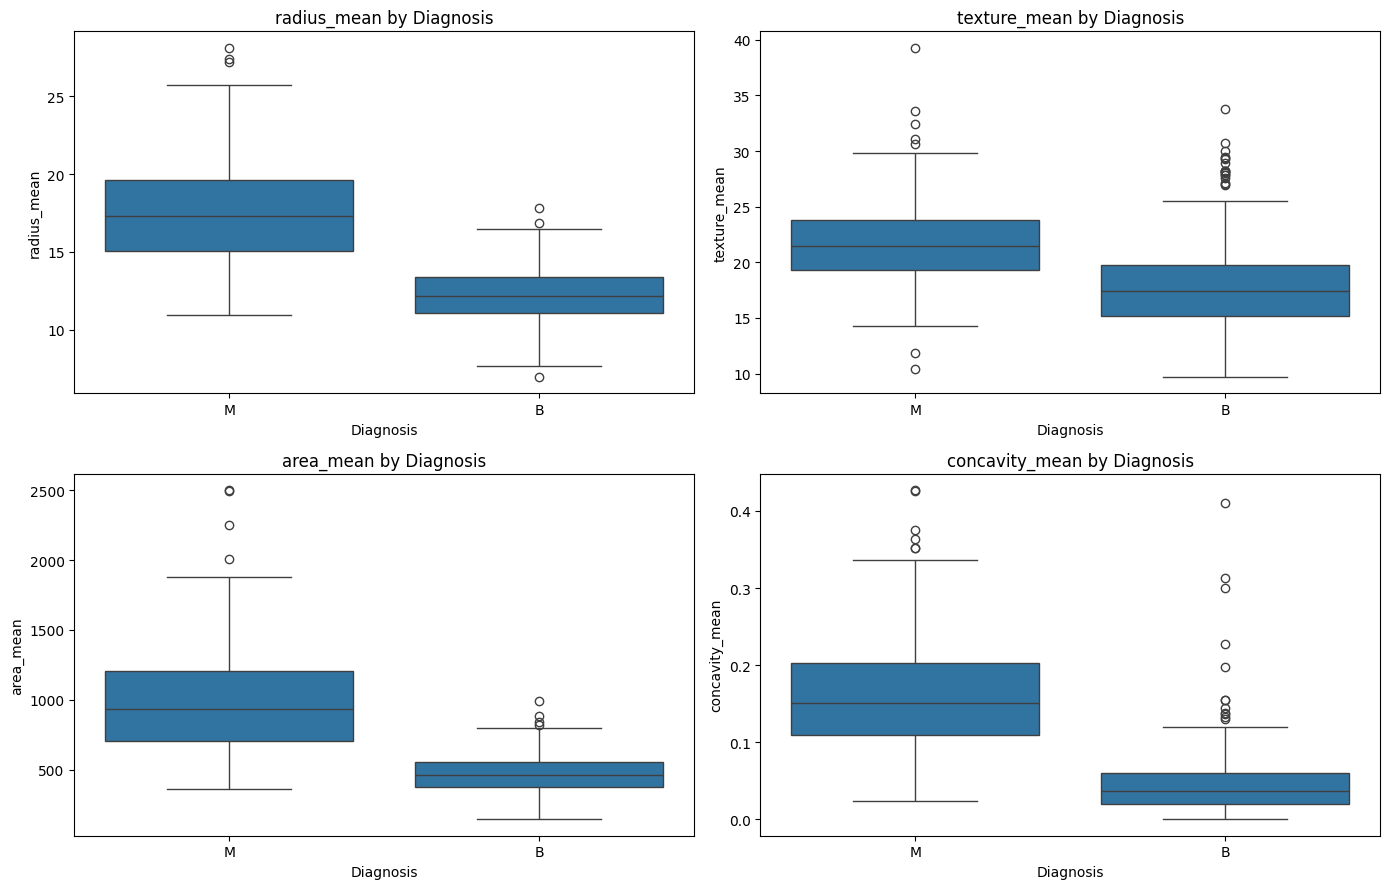

In [23]:
##  BOXPLOTS FOR SELECTED FEATURES
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes = axes.flatten()

for i, feature in enumerate(selected_features):

    sns.boxplot(
        data=df,
        x="diagnosis",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature} by Diagnosis"
    )

    axes[i].set_xlabel("Diagnosis")
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

#### Step 7 — Correlation & Multicollinearity Analysis

#### 7.1 Calculate the correlation matrix

In [24]:
## FEATURE CORRELATION MATRIX

correlation_matrix = df[feature_columns].corr()

print("Correlation matrix shape:", correlation_matrix.shape)

display(correlation_matrix.round(2))

Correlation matrix shape: (30, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.00,0.32,1.00,0.99,0.17,0.51,0.68,0.82,0.15,-0.31,...,0.97,0.30,0.97,0.94,0.12,0.41,0.53,0.74,0.16,0.01
texture_mean,0.32,1.00,0.33,0.32,-0.02,0.24,0.30,0.29,0.07,-0.08,...,0.35,0.91,0.36,0.34,0.08,0.28,0.30,0.30,0.11,0.12
perimeter_mean,1.00,0.33,1.00,0.99,0.21,0.56,0.72,0.85,0.18,-0.26,...,0.97,0.30,0.97,0.94,0.15,0.46,0.56,0.77,0.19,0.05
area_mean,0.99,0.32,0.99,1.00,0.18,0.50,0.69,0.82,0.15,-0.28,...,0.96,0.29,0.96,0.96,0.12,0.39,0.51,0.72,0.14,0.00
smoothness_mean,0.17,-0.02,0.21,0.18,1.00,0.66,0.52,0.55,0.56,0.58,...,0.21,0.04,0.24,0.21,0.81,0.47,0.43,0.50,0.39,0.50
compactness_mean,0.51,0.24,0.56,0.50,0.66,1.00,0.88,0.83,0.60,0.57,...,0.54,0.25,0.59,0.51,0.57,0.87,0.82,0.82,0.51,0.69
concavity_mean,0.68,0.30,0.72,0.69,0.52,0.88,1.00,0.92,0.50,0.34,...,0.69,0.30,0.73,0.68,0.45,0.75,0.88,0.86,0.41,0.51
concave points_mean,0.82,0.29,0.85,0.82,0.55,0.83,0.92,1.00,0.46,0.17,...,0.83,0.29,0.86,0.81,0.45,0.67,0.75,0.91,0.38,0.37
symmetry_mean,0.15,0.07,0.18,0.15,0.56,0.60,0.50,0.46,1.00,0.48,...,0.19,0.09,0.22,0.18,0.43,0.47,0.43,0.43,0.70,0.44
fractal_dimension_mean,-0.31,-0.08,-0.26,-0.28,0.58,0.57,0.34,0.17,0.48,1.00,...,-0.25,-0.05,-0.21,-0.23,0.50,0.46,0.35,0.18,0.33,0.77


#### 7.2 Correlation heatmap

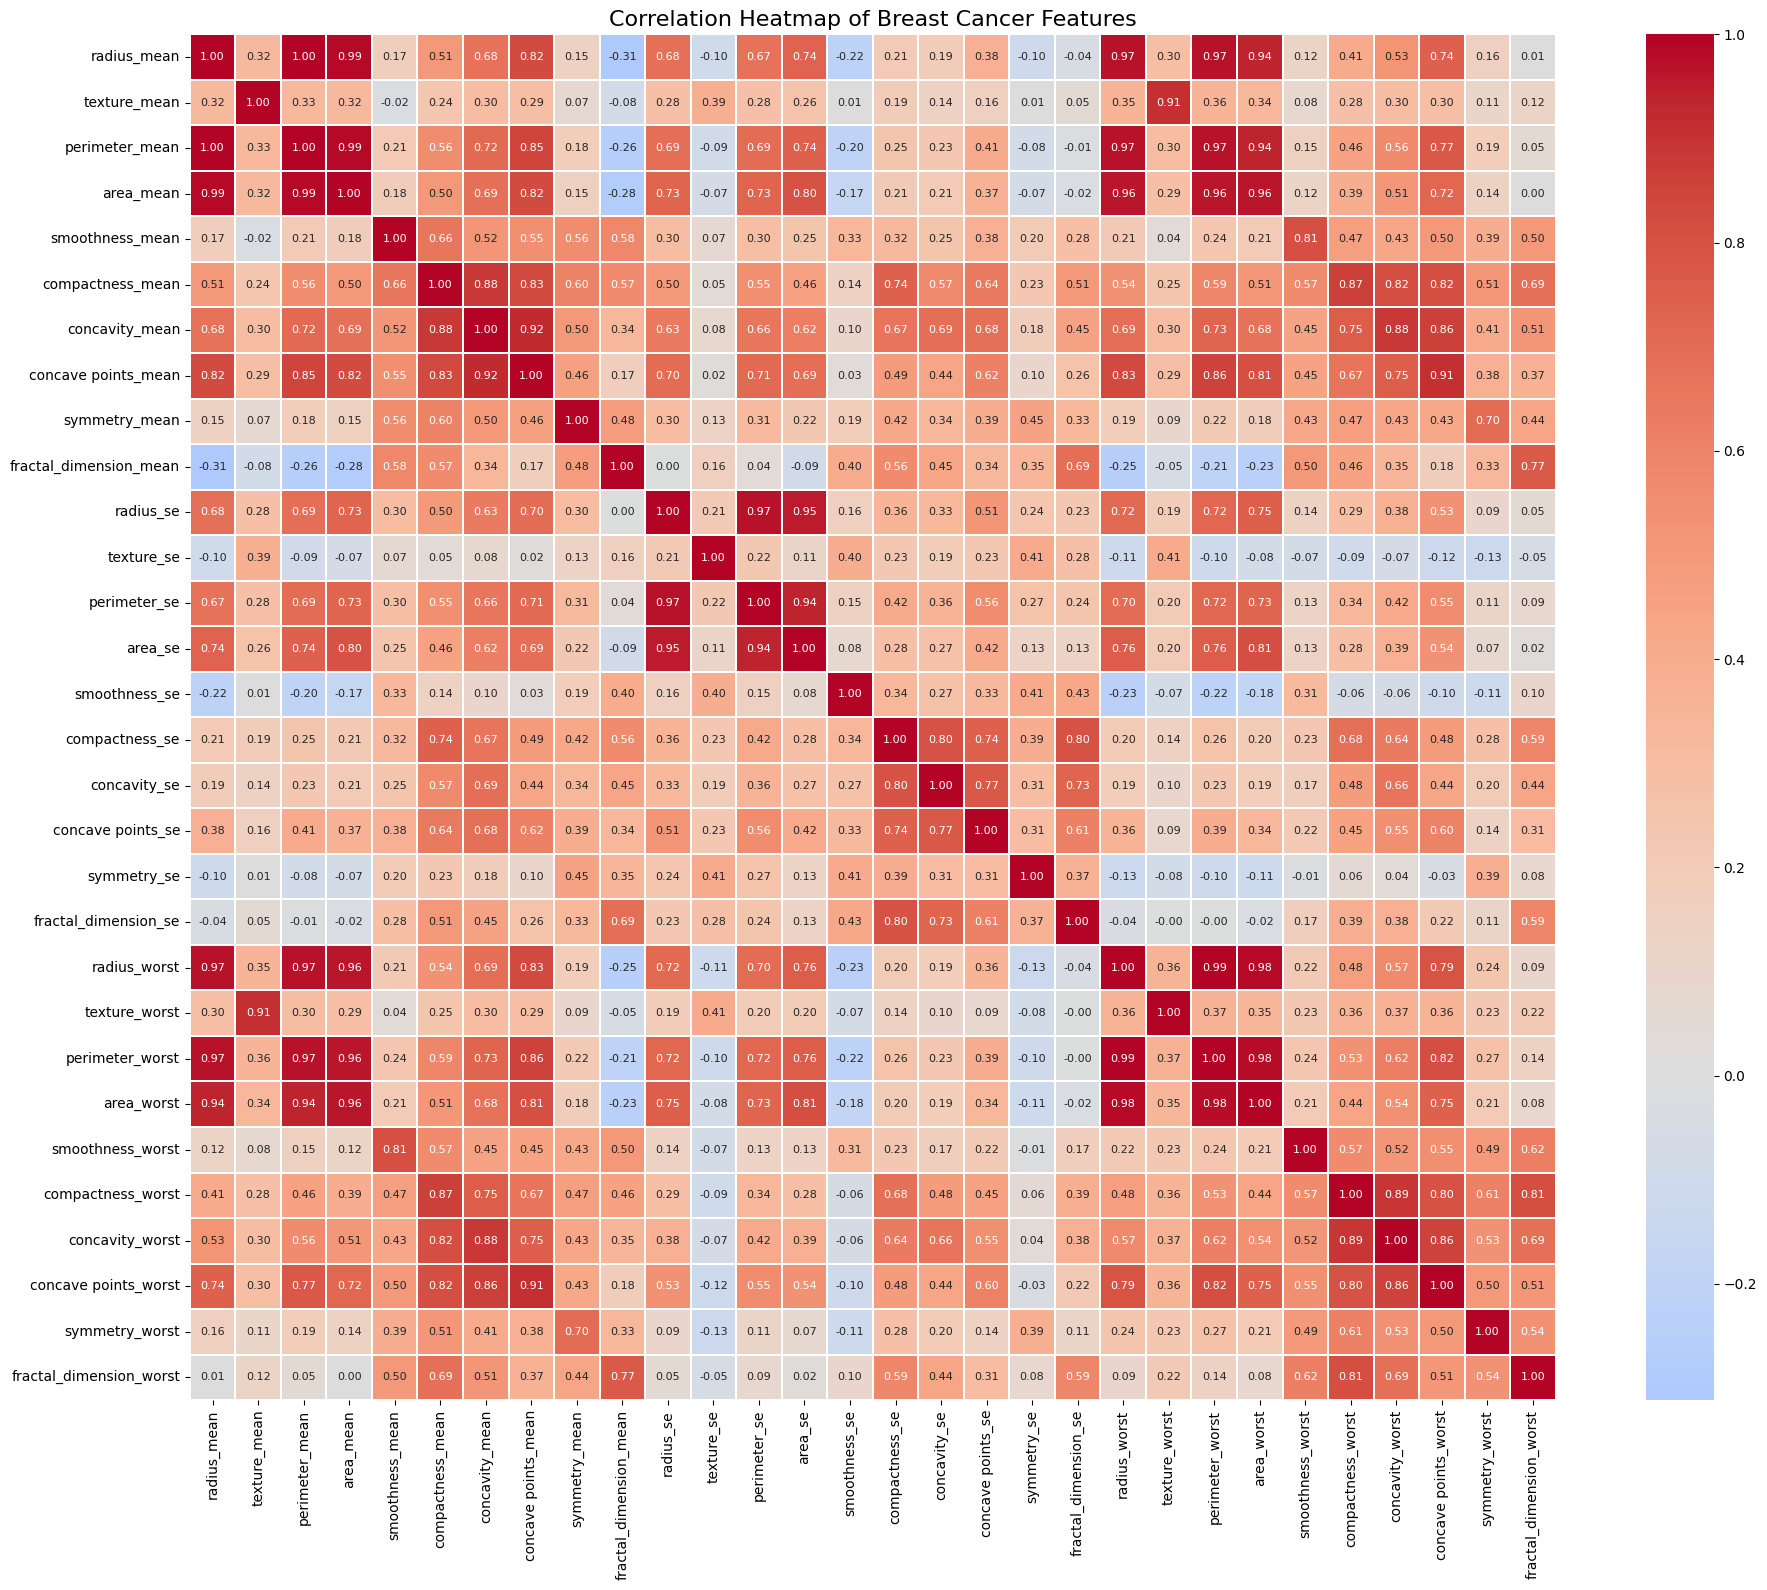

In [27]:
## CORRELATION HEATMAP
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    annot = True,
    fmt = ".2f",
    annot_kws={"size": 8}

)

plt.title(
    "Correlation Heatmap of Breast Cancer Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### 7.3 Find highly correlated feature pairs

In [26]:
## IDENTIFY HIGHLY CORRELATED FEATURE PAIRS
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.90:

            high_corr_pairs.append({
                "Feature_1": correlation_matrix.columns[i],
                "Feature_2": correlation_matrix.columns[j],
                "Correlation": correlation
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df["Absolute_Correlation"] = (
    high_corr_df["Correlation"].abs()
)

high_corr_df = high_corr_df.sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(high_corr_df)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,perimeter_mean,radius_mean,0.997855,0.997855
14,perimeter_worst,radius_worst,0.993708,0.993708
1,area_mean,radius_mean,0.987357,0.987357
2,area_mean,perimeter_mean,0.986507,0.986507
18,area_worst,radius_worst,0.984015,0.984015
19,area_worst,perimeter_worst,0.977578,0.977578
4,perimeter_se,radius_se,0.972794,0.972794
12,perimeter_worst,perimeter_mean,0.970387,0.970387
7,radius_worst,radius_mean,0.969539,0.969539
8,radius_worst,perimeter_mean,0.969476,0.969476


#### 7.4 Count very highly correlated pairs

In [28]:
## HIGH CORRELATION SUMMARY

print(
    "Number of feature pairs with |correlation| >= 0.90:",
    len(high_corr_df)
)

display(
    high_corr_df[
        ["Feature_1", "Feature_2", "Correlation"]
    ].head(15)
)

Number of feature pairs with |correlation| >= 0.90: 21


,Feature_1,Feature_2,Correlation
0,perimeter_mean,radius_mean,0.997855
14,perimeter_worst,radius_worst,0.993708
1,area_mean,radius_mean,0.987357
2,area_mean,perimeter_mean,0.986507
18,area_worst,radius_worst,0.984015
19,area_worst,perimeter_worst,0.977578
4,perimeter_se,radius_se,0.972794
12,perimeter_worst,perimeter_mean,0.970387
7,radius_worst,radius_mean,0.969539
8,radius_worst,perimeter_mean,0.969476


#### 7.5 Correlation with diagnosis

In [29]:
##  FEATURE CORRELATION WITH TARGET

diagnosis_temp = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

target_correlations = (
    df[feature_columns]
    .corrwith(diagnosis_temp)
    .sort_values(ascending=False)
)

target_corr_df = pd.DataFrame({
    "Correlation_with_Diagnosis": target_correlations
})

display(target_corr_df)

,Correlation_with_Diagnosis
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


#### 7.6 Visualize correlations with diagnosis

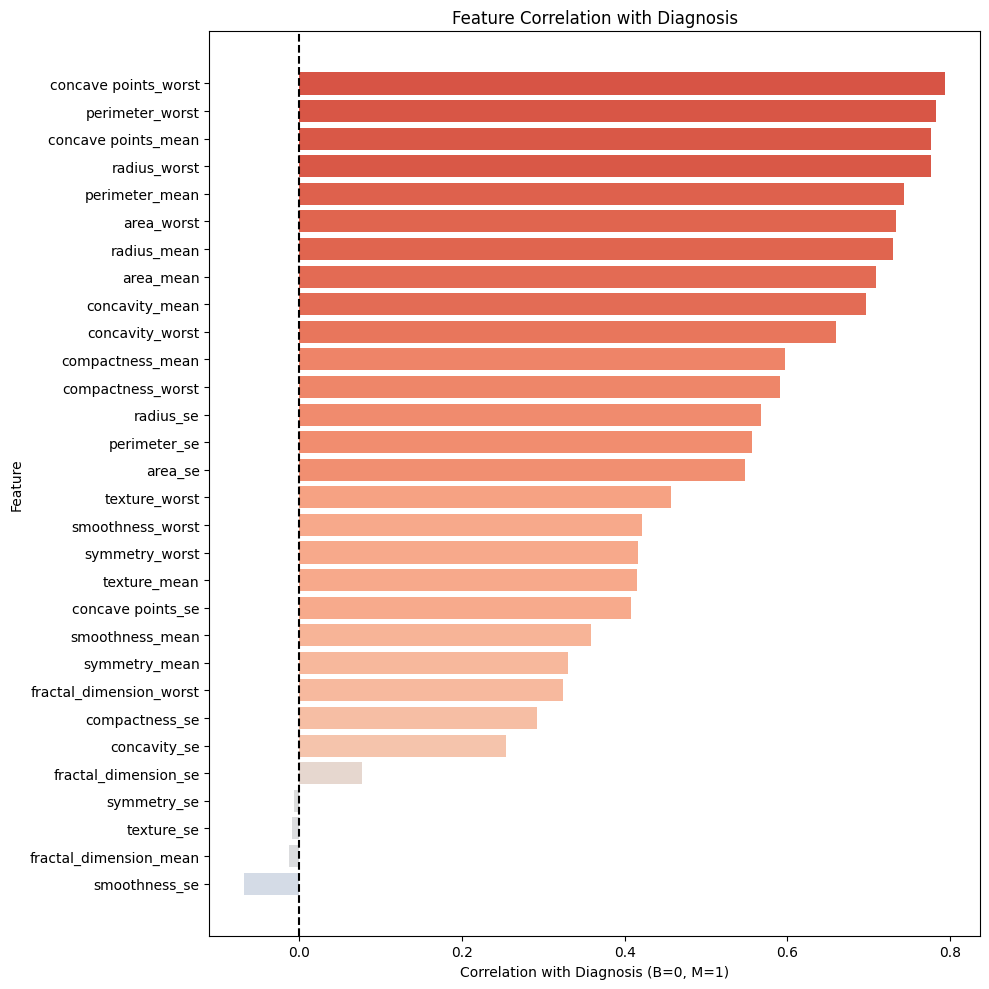

In [32]:
## TARGET CORRELATION BAR PLOT
import matplotlib.colors as mcolors

target_corr_sorted = target_corr_df.sort_values(
    "Correlation_with_Diagnosis"
)

values = target_corr_sorted["Correlation_with_Diagnosis"]

# Map correlations to coolwarm colors
norm = mcolors.Normalize(vmin=-1, vmax=1)
colors = plt.cm.coolwarm(norm(values))

plt.figure(figsize=(10, 10))

plt.barh(
    target_corr_sorted.index,
    values,
    color=colors
)

plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Correlation with Diagnosis (B=0, M=1)")
plt.ylabel("Feature")

plt.axvline(0, linestyle="--", color="black")

plt.tight_layout()
plt.show()

The dataset contains substantial feature redundancy, particularly among radius, perimeter and area measurements. Feature-selection strategies may therefore be evaluated during feature engineering/model development rather than removing correlated variables during initial data understanding.

### Step 8 — Outlier Assessment

#### 8.1 Calculate IQR outliers for all 30 features

In [33]:
## IQR OUTLIER ANALYSIS

outlier_summary = []

for feature in feature_columns:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(df)) * 100,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier_Percentage",
    ascending=False
)

display(outlier_df)

,Feature,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
13,area_se,65,11.423550,-23.160000,86.200000
10,radius_se,38,6.678383,-0.137350,0.848650
12,perimeter_se,38,6.678383,-1.020500,5.983500
23,area_worst,35,6.151142,-337.750000,1937.050000
14,smoothness_se,30,5.272408,0.000703,0.012612
19,fractal_dimension_se,28,4.920914,-0.001217,0.008023
15,compactness_se,28,4.920914,-0.015975,0.061505
18,symmetry_se,27,4.745167,0.002680,0.035960
3,area_mean,25,4.393673,-123.300000,1326.300000
29,fractal_dimension_worst,24,4.217926,0.040530,0.123010


#### 8.2 Show features with the most outliers

In [34]:
## FEATURES WITH MOST IQR OUTLIERS
display(
    outlier_df[
        ["Feature", "Outlier_Count", "Outlier_Percentage"]
    ].head(15)
)

,Feature,Outlier_Count,Outlier_Percentage
13,area_se,65,11.423550
10,radius_se,38,6.678383
12,perimeter_se,38,6.678383
23,area_worst,35,6.151142
14,smoothness_se,30,5.272408
19,fractal_dimension_se,28,4.920914
15,compactness_se,28,4.920914
18,symmetry_se,27,4.745167
3,area_mean,25,4.393673
29,fractal_dimension_worst,24,4.217926


#### 8.3 Check whether any feature has zero outliers

In [35]:
## OUTLIER SUMMARY
features_with_outliers = (
    outlier_df["Outlier_Count"] > 0
).sum()

features_without_outliers = (
    outlier_df["Outlier_Count"] == 0
).sum()

print("Total predictive features:", len(feature_columns))
print("Features containing IQR outliers:", features_with_outliers)
print("Features without IQR outliers:", features_without_outliers)

Total predictive features: 30
Features containing IQR outliers: 29
Features without IQR outliers: 1


#### 8.4 Visualize the outlier counts

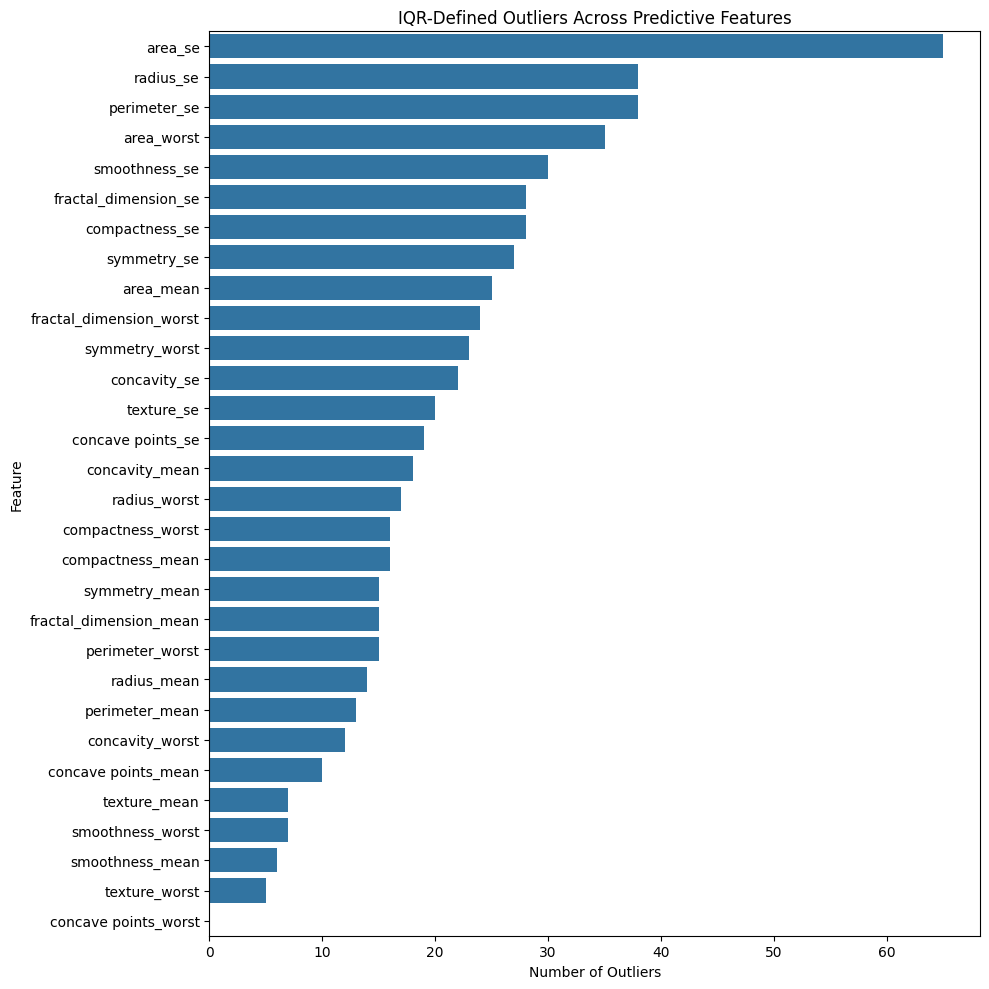

In [36]:
##  OUTLIER COUNT VISUALIZATION

plt.figure(figsize=(10, 10))

sns.barplot(
    data=outlier_df,
    x="Outlier_Count",
    y="Feature"
)

plt.title("IQR-Defined Outliers Across Predictive Features")
plt.xlabel("Number of Outliers")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

###  9. Data Understanding Summary

#### Dataset Overview

- The dataset contains **569 observations and 33 raw columns**.
- **30 columns** represent numerical tumour measurement features.
- `diagnosis` is the binary target variable.
- `id` is an identifier and does not represent a predictive tumour characteristic.
- `Unnamed: 32` is an empty CSV artifact containing 100% missing values.

#### Data Quality

- No duplicate rows were identified.
- The 30 predictive features contain no missing values.
- `Unnamed: 32` is completely empty and should be removed during preprocessing.
- No constant predictive features were identified.

#### Target Variable

- **Benign (B): 357 cases — 62.74%**
- **Malignant (M): 212 cases — 37.26%**
- The target therefore shows a moderate class imbalance.
- Classification performance should not be evaluated using accuracy alone.

#### Feature Distributions

- The predictive variables operate on substantially different numerical scales.
- Several features show strong positive/right skewness.
- `area_se`, `concavity_se`, `fractal_dimension_se`, `perimeter_se`, and `radius_se` are among the most highly skewed features.
- Malignant cases generally show larger values for several tumour size and shape measurements, particularly radius, area, perimeter, concavity, and concave-point measurements.

#### Correlation and Feature Redundancy

- Strong correlations exist between several predictive variables.
- **21 feature pairs have an absolute Pearson correlation >= 0.90.**
- Particularly strong relationships exist among radius, perimeter, and area measurements.
- `perimeter_mean` and `radius_mean` show a correlation of approximately **0.998**.
- Several worst-case tumour measurements also show strong correlation with their corresponding mean measurements.
- Highly correlated variables will not be removed during data understanding; feature redundancy can be evaluated later during feature engineering and model development.

#### Relationship with Diagnosis

Features showing strong positive linear association with malignant diagnosis include:

- `concave points_worst`
- `perimeter_worst`
- `concave points_mean`
- `radius_worst`
- `perimeter_mean`
- `area_worst`
- `radius_mean`
- `area_mean`

These correlations are exploratory associations and should not be interpreted as model-based feature importance.

#### Outlier Assessment

- IQR-based analysis identified potential outliers in **29 of 30 predictive features**.
- `area_se` contains the highest number of IQR-defined outliers: **65 observations (11.42%)**.
- The presence of an IQR outlier does not imply an erroneous measurement.
- Extreme tumour measurements may contain clinically relevant information, particularly for malignant cases.
- Therefore, observations will not be automatically removed solely because they are classified as statistical outliers.

#### Preprocessing Decisions for the Next Stage

The following actions will be carried forward to `02_Data_Cleaning_Preprocessing.ipynb`:

1. Remove the non-predictive `id` column.
2. Remove the empty `Unnamed: 32` column.
3. Encode `diagnosis` as:
   - Benign (`B`) = 0
   - Malignant (`M`) = 1
4. Separate predictors (`X`) and target (`y`).
5. Perform a stratified train/test split to preserve the class distribution.
6. Fit preprocessing transformations using the training data only to prevent data leakage.
7. Standardize numerical features before SVM modelling.
8. Retain IQR-defined outliers unless there is evidence that they represent invalid observations.
9. Preserve the initial 30-feature dataset and evaluate any feature-selection strategy separately rather than automatically removing correlated variables.